### Produce violin plots in R 

In [3]:
library(tidyverse)

In [1]:
plots_dir <- "plots/"

In [4]:
combined_results <- read.csv("combined_results.csv")
combined_results$region <- factor(combined_results$region, c("control", "RZ", "RZ_BZ",
                                                             "RZ_FZ", "RZ_GT", "IZ", "IZ_BZ", "GT_IZ", "FZ", "FZ_GT"))

In [5]:
combined_results %>% head()

,X,sample,prop_fetalization_spots,fetal_Moran,fetal_Moran_p,region,study,diseased_region
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>
1,0,Visium_IZ_P10,15.7981349,0.2045087,7.597754e-103,IZ,Kuppe 2022,Y
2,1,Visium_control_P1,2.8343874,0.3222172,9.148071e-295,control,Kuppe 2022,N
3,2,Visium_RZ_BZ_P3,0.6653788,0.3735908,0.000000e+00,RZ_BZ,Kuppe 2022,N
4,3,Visium_RZ_P11,2.5297619,0.2923067,3.929178e-117,RZ,Kuppe 2022,N
5,4,Visium_control_P8,0.4071661,0.2745921,3.686843e-125,control,Kuppe 2022,N
6,5,Visium_RZ_BZ_P12,0.5011792,0.4529909,0.000000e+00,RZ_BZ,Kuppe 2022,N


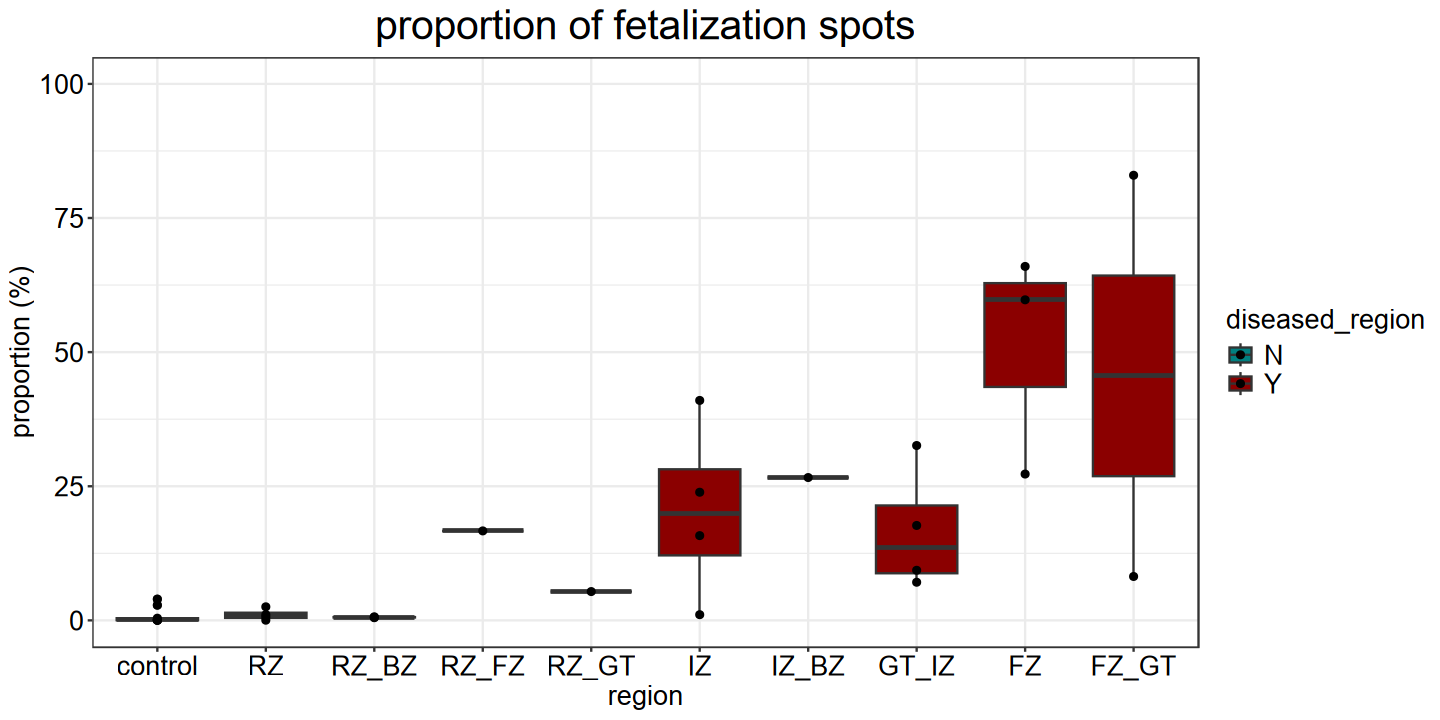

In [8]:
options(repr.plot.width = 12, repr.plot.height = 6)

p1 <- ggplot(data = combined_results, mapping = aes(x = region, y = prop_fetalization_spots, fill = diseased_region)) + 
geom_boxplot() + geom_point() + theme_bw() +
theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black")) + scale_fill_manual(values = c("Y" = "#8B0000", "N" = "#008080")) +
labs(x = "region", y = "proportion (%)", title = "proportion of fetalization spots") + ylim(0, 100)

p1 

ggsave(p1, filename = paste0(plots_dir, "percentage_of_fetalization_spots_across_spatial_regions.pdf"), height = 6, width = 12)

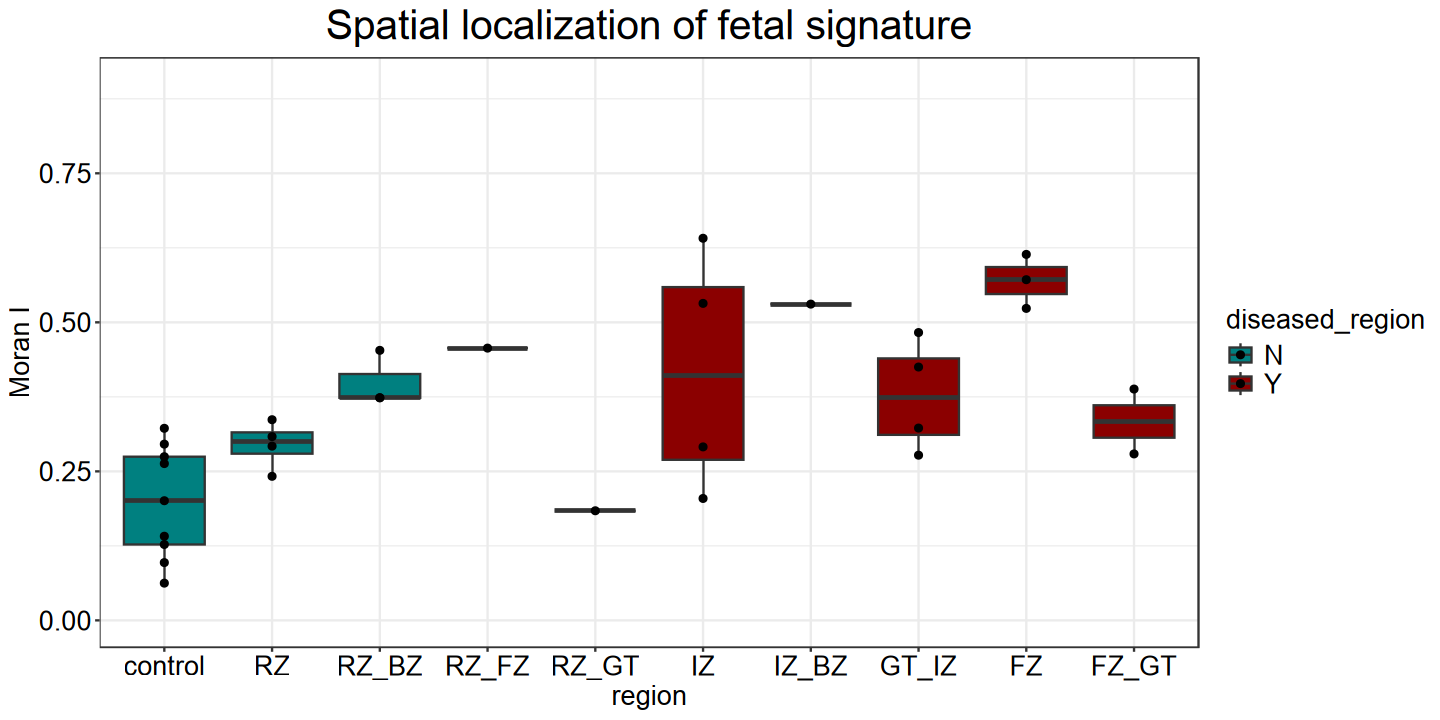

In [9]:
options(repr.plot.width = 12, repr.plot.height = 6)

p2 <- ggplot(data = combined_results, mapping = aes(x = region, y = fetal_Moran, fill = diseased_region)) + 
geom_boxplot() + geom_point() + theme_bw() +
theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black")) + scale_fill_manual(values = c("Y" = "#8B0000", "N" = "#008080")) +
labs(x = "region", y = "Moran I", title = "Spatial localization of fetal signature") + ylim(0, 0.9)

p2

ggsave(p2, filename = paste0(plots_dir, "Moran_I_across_spatial_regions.pdf"), height = 6, width = 12)